# Adaptive-Glimpse DETR (AG-DETR)
### Budget-aware sequential detection over a frozen foundation feature field

This notebook is the modernized successor to the RL box-refinement localizer. It keeps the
*sequential-decision* identity of that line of work but re-roots it on three changes that move it
from "improved 2015 method" toward a defensible CVPR contribution:

1. **Frozen foundation features, encoded once.** A frozen DINOv2 ViT produces a dense feature
   field. The model never touches pixels again — every query attends into the cached tokens.
   (This is what finally makes the ROI-caching idea *principled* instead of the lossy `pool45` hack.)
2. **Set-valued, continuous, language-free detection.** A small DETR-style decoder with a set of
   object queries does **multi-object** detection with **continuous** box refinement — deleting the
   single-object, discrete-9-action, class-oracle weaknesses in one move.
3. **A learned per-query halting policy (the actual novelty).** A PonderNet-style halting head lets
   *each query* decide how many refinement steps it needs. Easy objects exit early; hard ones keep
   refining. A single prior strength `LAMBDA_P` is the **compute budget dial**. The headline result
   is an **mAP-vs-compute curve** where adaptive halting matches fixed-depth accuracy at lower average
   compute — an axis where standard detectors, which spend equal compute everywhere, do not compete.

**Cost discipline (this is the point, not an afterthought):** the backbone is frozen (no backbone
gradients, encode-once), `d_model=256`, 6 decoder steps, ~20 queries. Trainable params are only a
few million; training is light. Making the model heavy would defeat the budget thesis.

**What to run:** set paths in **Config**, then run top to bottom. Use `BACKBONE="stub"` for an
instant offline dry-run of the whole pipeline; switch to `"dinov2_vits14"` for real training.


## Implementation plan (what each section delivers)

| Stage | Section | Purpose |
|---|---|---|
| 1 | Config | All knobs incl. the budget dial `LAMBDA_P` and `BACKBONE` |
| 2 | Frozen backbone | DINOv2 (encode-once) with a stub fallback for dry runs |
| 3 | Data | VOC2012 **multi-object** loader (proper detection, not 1 box/img) |
| 4 | Model | Decoder + iterative box refinement + class/box/halt heads |
| 5 | Matching + loss | Hungarian set matching + PonderNet ponder loss |
| 6 | Eval | COCO-style mAP + the **mAP-vs-compute curve** (adaptive vs fixed-depth) |
| 7 | Train | Light training loop, best-checkpoint on val mAP |
| 8 | Analyse | Compute curve plot, detection viz, per-query halt-depth viz |
| 9 | Ablations | The exact experiments a reviewer will demand |


In [1]:
# ============================== 1. CONFIG ==============================
import os, math, random, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

# ---- paths ----
PATH_VOC = "C:/Users/jesli/Downloads/pascal/VOC2012"   # <- your VOC2012 root
WEIGHTS_DIR = "./agdetr_weights"

# ---- backbone ----
BACKBONE  = "dinov2_vits14"   # "stub" for offline dry-run | "dinov2_vits14" (cheap) | "dinov2_vitb14"
IMG_SIZE  = 224               # must be divisible by 14 for DINOv2 (224 = 16*14 -> 256 tokens)

# ---- classes (multi-object; keep ALL instances of these per image) ----
SELECTED_CLASSES = ["bicycle", "aeroplane", "horse", "cat", "dog"]
NUM_CLASSES = len(SELECTED_CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(SELECTED_CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

# ---- model (kept deliberately small) ----
D_MODEL     = 256
N_HEADS     = 8
FF_DIM      = 1024
NUM_QUERIES = 20
NUM_STEPS   = 6      # max refinement depth = the compute axis we halt within

# ---- the budget dial ----
LAMBDA_P = 0.4       # geometric-prior halting rate; higher -> halt earlier -> cheaper
BETA     = 0.05      # weight on the ponder KL regularizer

# ---- loss weights (DETR conventions) ----
W_CLS, W_L1, W_GIOU, EOS_COEF = 1.0, 5.0, 2.0, 0.1

# ---- training ----
EPOCHS, BATCH_SIZE, LR, WEIGHT_DECAY = 30, 8, 1e-4, 1e-4
IMAGES_PER_CLASS = 400          # cap per class for the train split (oversample weak classes by editing)
VAL_PER_CLASS    = 60
GRAD_CLIP = 1.0
NUM_WORKERS = 0                 # 0 on Windows/notebooks: workers can't pickle notebook-defined classes.
                               # Frozen backbone => GPU-bound, so 0 workers costs almost nothing here.
SEED = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(WEIGHTS_DIR, exist_ok=True)
print("Device:", device, "| Backbone:", BACKBONE)


Device: cuda | Backbone: dinov2_vits14


In [2]:
# ============================== box utilities ==============================
def box_cxcywh_to_xyxy(b):
    cx, cy, w, h = b.unbind(-1)
    return torch.stack([cx-0.5*w, cy-0.5*h, cx+0.5*w, cy+0.5*h], dim=-1)

def box_xyxy_to_cxcywh(b):
    x0, y0, x1, y1 = b.unbind(-1)
    return torch.stack([(x0+x1)/2, (y0+y1)/2, (x1-x0), (y1-y0)], dim=-1)

def box_area(b):
    return (b[...,2]-b[...,0]).clamp(min=0) * (b[...,3]-b[...,1]).clamp(min=0)

def generalized_box_iou(b1, b2):
    a1 = box_area(b1)[:, None]; a2 = box_area(b2)[None, :]
    lt = torch.max(b1[:,None,:2], b2[None,:,:2]); rb = torch.min(b1[:,None,2:], b2[None,:,2:])
    wh = (rb-lt).clamp(min=0); inter = wh[...,0]*wh[...,1]; union = a1+a2-inter
    iou = inter/union.clamp(min=1e-7)
    lt_c = torch.min(b1[:,None,:2], b2[None,:,:2]); rb_c = torch.max(b1[:,None,2:], b2[None,:,2:])
    wh_c = (rb_c-lt_c).clamp(min=0); area_c = wh_c[...,0]*wh_c[...,1]
    return iou - (area_c-union)/area_c.clamp(min=1e-7)

def inverse_sigmoid(x, eps=1e-5):
    x = x.clamp(0,1)
    return torch.log(x.clamp(min=eps)/(1-x).clamp(min=eps))


In [3]:
# ============================== 2. FROZEN BACKBONE ==============================
class FrozenBackbone(nn.Module):
    '''Returns patch tokens (B,N,C) and grid (h,w). DINOv2 encodes the image ONCE.'''
    def __init__(self, mode=BACKBONE, img_size=IMG_SIZE):
        super().__init__()
        self.mode = mode; self.img_size = img_size
        if mode == "stub":
            self.net = nn.Sequential(
                nn.Conv2d(3,64,7,2,3), nn.GroupNorm(8,64), nn.GELU(),
                nn.Conv2d(64,192,3,2,1), nn.GroupNorm(8,192), nn.GELU(),
                nn.Conv2d(192,384,3,2,1))
            self.embed_dim = 384; self.grid = 16
            self.pool = nn.AdaptiveAvgPool2d((self.grid, self.grid))
        else:
            self.net = torch.hub.load("facebookresearch/dinov2", mode)
            self.embed_dim = self.net.embed_dim; self.grid = img_size // 14
        for p in self.parameters(): p.requires_grad_(False)
        self.eval()

    @torch.no_grad()
    def forward(self, x):
        if self.mode == "stub":
            f = self.pool(self.net(x)); B,C,h,w = f.shape
            return f.flatten(2).transpose(1,2), (h,w)
        out = self.net.forward_features(x)
        return out["x_norm_patchtokens"], (self.grid, self.grid)

backbone = FrozenBackbone().to(device)
print("Backbone embed_dim:", backbone.embed_dim, "| token grid:",
      backbone.grid, "x", backbone.grid, "=", backbone.grid**2, "tokens")


Using cache found in C:\Users\jesli/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jesli/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jesli/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jesli/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Backbone embed_dim: 384 | token grid: 16 x 16 = 256 tokens


In [4]:
# ============================== 3. DATA (VOC2012, MULTI-OBJECT) ==============================
import xml.etree.ElementTree as ET
from PIL import Image
from torch.utils.data import Dataset, DataLoader

IMAGENET_MEAN = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

def list_split(class_name, split, path_voc):
    '''Image ids that contain `class_name` (positives) in {class}_{split}.txt.'''
    f = os.path.join(path_voc, "ImageSets", "Main", f"{class_name}_{split}.txt")
    ids = []
    with open(f) as fh:
        for line in fh:
            p = line.split()
            if len(p) >= 2 and p[1] != "-1":
                ids.append(p[0])
    return ids

def read_objects(img_id, path_voc, keep_difficult=False):
    '''All objects of SELECTED_CLASSES in an image -> (labels, xyxy abs), plus W,H.'''
    tree = ET.parse(os.path.join(path_voc, "Annotations", f"{img_id}.xml"))
    root = tree.getroot()
    size = root.find("size"); W = int(size.find("width").text); H = int(size.find("height").text)
    labels, boxes = [], []
    for obj in root.findall("object"):
        name = obj.find("name").text
        if name not in CLASS_TO_IDX: continue
        if (not keep_difficult) and obj.find("difficult") is not None \
           and obj.find("difficult").text == "1": continue
        bb = obj.find("bndbox")
        boxes.append([float(bb.find("xmin").text), float(bb.find("ymin").text),
                      float(bb.find("xmax").text), float(bb.find("ymax").text)])
        labels.append(CLASS_TO_IDX[name])
    return labels, boxes, W, H

class VOCDetectionMulti(Dataset):
    def __init__(self, ids, path_voc, img_size=IMG_SIZE):
        self.ids = ids; self.path = path_voc; self.S = img_size
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        img_id = self.ids[i]
        img = Image.open(os.path.join(self.path,"JPEGImages",f"{img_id}.jpg")).convert("RGB")
        labels, boxes, W, H = read_objects(img_id, self.path)
        img = img.resize((self.S, self.S))
        x = torch.from_numpy(np.asarray(img, np.float32)/255.).permute(2,0,1)
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
        if len(boxes):
            b = torch.tensor(boxes, dtype=torch.float32)
            b[:, [0,2]] /= W; b[:, [1,3]] /= H            # normalize to [0,1]
            cxcywh = box_xyxy_to_cxcywh(b).clamp(0,1)
            lab = torch.tensor(labels, dtype=torch.long)
        else:
            cxcywh = torch.zeros(0,4); lab = torch.zeros(0,dtype=torch.long)
        target = {"labels": lab, "boxes": cxcywh, "img_id": img_id,
                  "orig_size": (W,H)}
        return x, target

def collate(batch):
    xs = torch.stack([b[0] for b in batch], 0)
    targets = [b[1] for b in batch]
    return xs, targets

def build_ids(split, per_class):
    seen, ids = set(), []
    for c in SELECTED_CLASSES:
        pool = list_split(c, split, PATH_VOC)
        random.shuffle(pool)
        for img_id in pool[:per_class]:
            if img_id not in seen:
                seen.add(img_id); ids.append(img_id)
    random.shuffle(ids); return ids

# Build loaders only when a real dataset path exists (skip during stub dry-run).
HAVE_VOC = os.path.isdir(os.path.join(PATH_VOC, "Annotations"))
if HAVE_VOC:
    train_ids = build_ids("trainval", IMAGES_PER_CLASS)
    val_ids   = build_ids("val", VAL_PER_CLASS)
    train_ld = DataLoader(VOCDetectionMulti(train_ids, PATH_VOC), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate, drop_last=True)
    val_ld   = DataLoader(VOCDetectionMulti(val_ids, PATH_VOC), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate)
    print(f"train images: {len(train_ids)} | val images: {len(val_ids)}")
else:
    print("VOC not found at PATH_VOC -> dataset loaders skipped (use stub cells to dry-run).")


train images: 1994 | val images: 300


In [5]:
# ============================== 4. MODEL ==============================
class DecoderLayer(nn.Module):
    def __init__(self, d, nhead, ff):
        super().__init__()
        self.sa = nn.MultiheadAttention(d, nhead, batch_first=True)
        self.ca = nn.MultiheadAttention(d, nhead, batch_first=True)
        self.ln1, self.ln2, self.ln3 = nn.LayerNorm(d), nn.LayerNorm(d), nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Linear(ff, d))
    def forward(self, q, mem, qpos):
        qk = q + qpos
        q = self.ln1(q + self.sa(qk, qk, q)[0])
        q = self.ln2(q + self.ca(q + qpos, mem, mem)[0])
        q = self.ln3(q + self.ff(q))
        return q

class MLP(nn.Module):
    def __init__(self, d, hidden, out, layers=3):
        super().__init__()
        dims = [d] + [hidden]*(layers-1) + [out]
        self.net = nn.ModuleList(nn.Linear(dims[i], dims[i+1]) for i in range(layers))
    def forward(self, x):
        for i,l in enumerate(self.net):
            x = F.relu(l(x)) if i < len(self.net)-1 else l(x)
        return x

class AGDETR(nn.Module):
    def __init__(self, backbone, num_classes=NUM_CLASSES, d=D_MODEL, nhead=N_HEADS,
                 ff=FF_DIM, num_queries=NUM_QUERIES, num_steps=NUM_STEPS):
        super().__init__()
        self.backbone = backbone; self.num_classes = num_classes; self.num_steps = num_steps
        self.input_proj = nn.Linear(backbone.embed_dim, d)
        self.level_pos = nn.Parameter(torch.zeros(1, backbone.grid**2, d)); nn.init.normal_(self.level_pos, std=.02)
        self.query_embed = nn.Embedding(num_queries, d)
        self.query_pos   = nn.Embedding(num_queries, d)
        self.layers     = nn.ModuleList(DecoderLayer(d, nhead, ff) for _ in range(num_steps))
        self.class_head = nn.ModuleList(nn.Linear(d, num_classes+1) for _ in range(num_steps))
        self.box_head   = nn.ModuleList(MLP(d, d, 4) for _ in range(num_steps))
        self.halt_head  = nn.ModuleList(MLP(d, d//2, 1, layers=2) for _ in range(num_steps))
        self.ref_init   = nn.Linear(d, 4)
    def forward(self, images, max_step=None):
        max_step = max_step or self.num_steps
        tok, _ = self.backbone(images)                       # frozen, encode-once
        mem = self.input_proj(tok) + self.level_pos
        B = mem.size(0)
        q    = self.query_embed.weight[None].expand(B,-1,-1)
        qpos = self.query_pos.weight[None].expand(B,-1,-1)
        ref  = self.ref_init(q).sigmoid()
        cls_s, box_s, lam_s = [], [], []
        for n in range(max_step):
            q = self.layers[n](q, mem, qpos)
            logits = self.class_head[n](q)
            ref = (self.box_head[n](q) + inverse_sigmoid(ref)).sigmoid()
            lam = self.halt_head[n](q).squeeze(-1)
            cls_s.append(logits); box_s.append(ref); lam_s.append(lam)
            ref = ref.detach()
        return torch.stack(cls_s,0), torch.stack(box_s,0), torch.stack(lam_s,0)

model = AGDETR(backbone).to(device)
ntr = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {ntr/1e6:.2f}M  (backbone frozen)")


Trainable params: 7.50M  (backbone frozen)


In [6]:
# ============================== 5. MATCHING + PONDER LOSS ==============================
from scipy.optimize import linear_sum_assignment

@torch.no_grad()
def hungarian_match(cls_logits, boxes, targets, c_cls=1.0, c_l1=5.0, c_giou=2.0):
    B, Q, _ = cls_logits.shape
    prob = cls_logits.softmax(-1); out = []
    for b in range(B):
        t = targets[b]
        if t["labels"].numel() == 0:
            out.append((torch.empty(0,dtype=torch.long), torch.empty(0,dtype=torch.long))); continue
        pb, pc = boxes[b], prob[b]
        tb, tl = t["boxes"].to(boxes.device), t["labels"].to(boxes.device)
        cost = (c_cls*(-pc[:, tl]) + c_l1*torch.cdist(pb, tb, p=1)
                + c_giou*(-generalized_box_iou(box_cxcywh_to_xyxy(pb), box_cxcywh_to_xyxy(tb))))
        qi, gi = linear_sum_assignment(cost.cpu().numpy())
        out.append((torch.as_tensor(qi,dtype=torch.long), torch.as_tensor(gi,dtype=torch.long)))
    return out

def geometric_prior(S, lam_p, device):
    n = torch.arange(1, S+1, device=device, dtype=torch.float32)
    p = ((1-lam_p)**(n-1))*lam_p; return p/p.sum()

def ponder_set_loss(cls, box, lam_logit, targets):
    '''Match once on the final step; weight per-step DETR losses by ponder p_n;
    regularize halting toward a geometric prior (the budget term).'''
    S, B, Q, _ = cls.shape; device = cls.device; bg = NUM_CLASSES
    lam = lam_logit.sigmoid().clone(); lam[-1] = 1.0
    one_minus = (1-lam).clamp(min=1e-6)
    cum = torch.cumprod(one_minus, 0)
    shift = torch.cat([torch.ones_like(cum[:1]), cum[:-1]], 0)
    p = lam*shift; p = p/p.sum(0, keepdim=True).clamp(min=1e-6)        # (S,B,Q)

    match = hungarian_match(cls[-1], box[-1], targets)
    tgt_label = torch.full((B,Q), bg, dtype=torch.long, device=device)
    tgt_box   = torch.zeros(B,Q,4, device=device)
    box_mask  = torch.zeros(B,Q, dtype=torch.bool, device=device)
    for b,(qi,gi) in enumerate(match):
        if qi.numel():
            tgt_label[b,qi] = targets[b]["labels"][gi].to(device)
            tgt_box[b,qi]   = targets[b]["boxes"][gi].to(device)
            box_mask[b,qi]  = True

    cls_w = torch.ones(NUM_CLASSES+1, device=device); cls_w[bg] = EOS_COEF
    ce = F.cross_entropy(cls.reshape(S*B*Q,-1),
                         tgt_label[None].expand(S,B,Q).reshape(-1),
                         weight=cls_w, reduction="none").reshape(S,B,Q)
    l1 = F.l1_loss(box, tgt_box[None].expand(S,B,Q,4), reduction="none").sum(-1)
    giou_term = torch.zeros(S,B,Q, device=device)
    if box_mask.any():
        for s in range(S):
            gv = generalized_box_iou(box_cxcywh_to_xyxy(box[s][box_mask]),
                                     box_cxcywh_to_xyxy(tgt_box[box_mask]))
            giou_term[s][box_mask] = 1 - torch.diag(gv)
    det = W_CLS*ce + (W_L1*l1 + W_GIOU*giou_term)*box_mask[None].float()  # (S,B,Q)
    # Two detection terms, deliberately separated:
    #  (a) EQUAL-weight deep supervision: every layer must be a usable detector.
    #      This is what produces a smooth anytime curve (vs accuracy piling up only
    #      at the final layer). Without it the halting head starves early layers.
    #  (b) PONDER-weighted term: pushes the halting head to prefer the earliest
    #      layer that is already good.
    L_equal  = det.mean(0)            # (B,Q)
    L_ponder = (p*det).sum(0)         # (B,Q)

    prior = geometric_prior(S, LAMBDA_P, device)[:,None,None]
    kl = (p*(torch.log(p.clamp(min=1e-6)) - torch.log(prior))).sum(0)

    num_obj = max(1, int(box_mask.sum().item()))
    total = (L_equal.sum() + L_ponder.sum())/num_obj + BETA*kl.mean()
    with torch.no_grad():
        exp_steps = (p*torch.arange(1,S+1,device=device)[:,None,None]).sum(0).mean().item()
    return total, {"aux": (L_equal.sum()/num_obj).item(),
                   "rec": (L_ponder.sum()/num_obj).item(), "kl": kl.mean().item(),
                   "exp_steps": exp_steps, "num_obj": num_obj}


In [7]:
# ============================== 6. EVAL: mAP + COMPUTE CURVE ==============================
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

@torch.no_grad()
def postprocess(cls_step, box_step, img_sizes, score_thresh=0.0):
    prob = cls_step.softmax(-1)[..., :-1]
    scores, labels = prob.max(-1)
    preds = []
    for b in range(cls_step.size(0)):
        W, H = img_sizes[b]
        xyxy = box_cxcywh_to_xyxy(box_step[b])
        xyxy = (xyxy * torch.tensor([W,H,W,H], device=xyxy.device)).clamp(min=0)
        keep = scores[b] > score_thresh
        preds.append({"boxes": xyxy[keep], "scores": scores[b][keep], "labels": labels[b][keep]})
    return preds

@torch.no_grad()
def halt_steps(lam_logit):
    S,B,Q = lam_logit.shape
    lam = lam_logit.sigmoid().clone(); lam[-1] = 1.0
    cum = torch.cumprod((1-lam).clamp(min=1e-6), 0)
    shift = torch.cat([torch.ones_like(cum[:1]), cum[:-1]], 0)
    p = lam*shift
    return p.argmax(0)+1, p

@torch.no_grad()
def adaptive_readout(cls, box, lam_logit, img_sizes):
    S,B,Q,_ = cls.shape
    hs,_ = halt_steps(lam_logit); idx = hs-1
    cls_sel = torch.gather(cls, 0, idx[None,...,None].expand(1,B,Q,cls.size(-1)))[0]
    box_sel = torch.gather(box, 0, idx[None,...,None].expand(1,B,Q,4))[0]
    return postprocess(cls_sel, box_sel, img_sizes), hs.float().mean().item()

@torch.no_grad()
def evaluate(model, loader, mode="adaptive", fixed_depth=None, progress=False):
    '''mode: 'adaptive' (per-query halting) or 'fixed' (uniform depth=fixed_depth).
    Returns (mAP_dict, avg_steps_used).'''
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy")
    step_acc, n = 0.0, 0
    desc = "eval (adaptive)" if mode == "adaptive" else f"eval (depth {fixed_depth})"
    it = tqdm(loader, desc=desc, leave=False) if progress else loader
    for xs, targets in it:
        xs = xs.to(device)
        sizes = [(IMG_SIZE, IMG_SIZE)] * xs.size(0)
        if mode == "fixed":
            cls, box, lam = model(xs, max_step=fixed_depth)
            preds = postprocess(cls[-1], box[-1], sizes)
            step_acc += fixed_depth * xs.size(0)
        else:
            cls, box, lam = model(xs)
            preds, avg = adaptive_readout(cls, box, lam, sizes)
            step_acc += avg * xs.size(0)
        gts = [{"boxes": (box_cxcywh_to_xyxy(t["boxes"])*IMG_SIZE).to(device),
                "labels": t["labels"].to(device)} for t in targets]
        metric.update(preds, gts); n += xs.size(0)
    res = metric.compute()
    return {k: float(v) for k,v in res.items() if v.numel()==1}, step_acc/max(1,n)

def compute_curve(model, loader):
    '''The headline plot data: fixed-depth points + the adaptive point.'''
    pts = []
    for k in tqdm(range(1, NUM_STEPS+1), desc="compute curve"):
        m, s = evaluate(model, loader, mode="fixed", fixed_depth=k)
        pts.append(("fixed", k, s, m["map"], m.get("map_50", float("nan"))))
    m, s = evaluate(model, loader, mode="adaptive")
    pts.append(("adaptive", None, s, m["map"], m.get("map_50", float("nan"))))
    return pts


In [8]:
# ============================== 7. TRAIN ==============================
from tqdm.auto import tqdm

def train():
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                            lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    best_map, best_path = -1.0, os.path.join(WEIGHTS_DIR, "agdetr_best.pth")
    history = []

    for epoch in range(EPOCHS):
        model.train(); backbone.eval()        # backbone always frozen/eval
        t0 = time.time()
        run = {"loss": 0., "rec": 0., "kl": 0., "steps": 0., "n": 0}
        pbar = tqdm(train_ld, desc=f"epoch {epoch+1}/{EPOCHS}", leave=False)
        for xs, targets in pbar:
            xs = xs.to(device)
            cls, box, lam = model(xs)
            loss, logs = ponder_set_loss(cls, box, lam, targets)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP); opt.step()
            run["n"] += 1
            run["loss"]  += loss.item(); run["rec"] += logs["rec"]
            run["kl"]    += logs["kl"];  run["steps"] += logs["exp_steps"]
            pbar.set_postfix(loss=f'{run["loss"]/run["n"]:.3f}',
                             rec=f'{run["rec"]/run["n"]:.3f}',
                             halt=f'{run["steps"]/run["n"]:.2f}',
                             lr=f'{sched.get_last_lr()[0]:.1e}')
        sched.step()

        m, avg = evaluate(model, val_ld, mode="adaptive", progress=True)
        dt = time.time() - t0
        tr_loss = run["loss"]/max(1, run["n"])
        print(f"epoch {epoch+1:02d} | train loss {tr_loss:.3f} "
              f"halt {run['steps']/max(1,run['n']):.2f} | "
              f"val mAP {m['map']:.4f}  mAP50 {m.get('map_50', float('nan')):.4f} | "
              f"adaptive steps {avg:.2f}/{NUM_STEPS} | {dt:.0f}s")
        history.append({"epoch": epoch+1, "train_loss": tr_loss,
                        "val_map": m["map"], "val_map50": m.get("map_50", float("nan")),
                        "adaptive_steps": avg})
        if m["map"] > best_map:
            best_map = m["map"]; torch.save(model.state_dict(), best_path)
            print(f"   ** new best mAP {best_map:.4f} -> saved {os.path.basename(best_path)}")

    print(f"\nbest val mAP: {best_map:.4f}")
    return best_path, history

if HAVE_VOC:
    best_path, history = train()
else:
    print("Skipping training (no VOC). Set PATH_VOC and BACKBONE, then re-run.")


epoch 1/30:   0%|          | 0/249 [00:00<?, ?it/s]

eval (adaptive):   0%|          | 0/38 [00:00<?, ?it/s]

epoch 01 | train loss 11.433 halt 2.60 | val mAP 0.0130  mAP50 0.0460 | adaptive steps 2.79/6 | 57s
   ** new best mAP 0.0130 -> saved agdetr_best.pth


epoch 2/30:   0%|          | 0/249 [00:00<?, ?it/s]

eval (adaptive):   0%|          | 0/38 [00:00<?, ?it/s]

...

eval (adaptive):   0%|          | 0/38 [00:00<?, ?it/s]

epoch 29 | train loss 2.474 halt 4.19 | val mAP 0.4106  mAP50 0.7578 | adaptive steps 3.75/6 | 107s


epoch 30/30:   0%|          | 0/249 [00:00<?, ?it/s]

eval (adaptive):   0%|          | 0/38 [00:00<?, ?it/s]

epoch 30 | train loss 2.451 halt 4.18 | val mAP 0.4116  mAP50 0.7577 | adaptive steps 3.74/6 | 109s

best val mAP: 0.4120


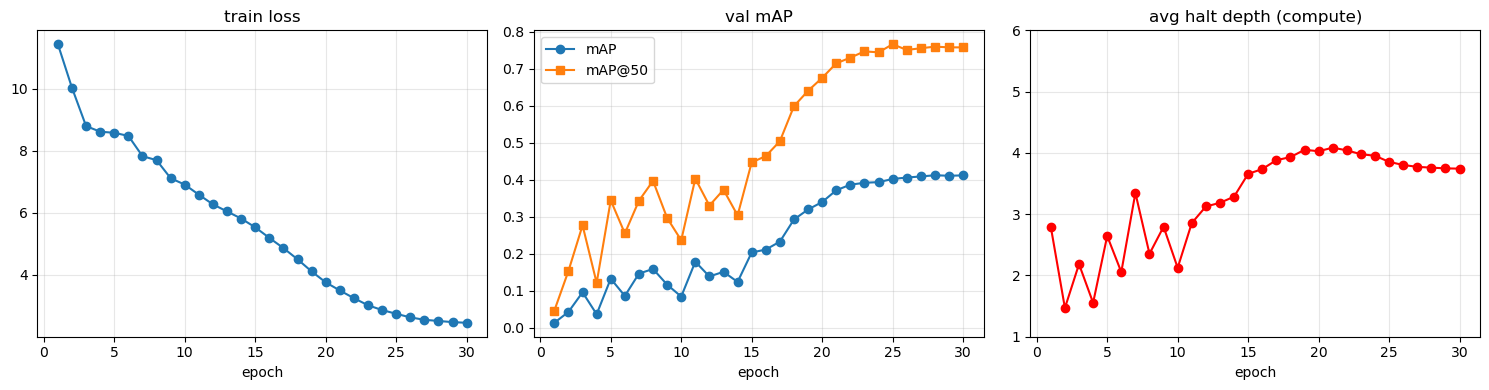

In [9]:
# ============================== 7b. TRAINING CURVES ==============================
import matplotlib.pyplot as plt

if HAVE_VOC and len(history):
    ep   = [h["epoch"] for h in history]
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(ep, [h["train_loss"] for h in history], "o-"); ax[0].set_title("train loss")
    ax[0].set_xlabel("epoch"); ax[0].grid(alpha=.3)
    ax[1].plot(ep, [h["val_map"] for h in history], "o-", label="mAP")
    ax[1].plot(ep, [h["val_map50"] for h in history], "s-", label="mAP@50")
    ax[1].set_title("val mAP"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    ax[2].plot(ep, [h["adaptive_steps"] for h in history], "o-", color="red")
    ax[2].set_title("avg halt depth (compute)"); ax[2].set_xlabel("epoch")
    ax[2].set_ylim(1, NUM_STEPS); ax[2].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(os.path.join(WEIGHTS_DIR, "training_curves.png"), dpi=120); plt.show()


C:\Users\jesli\AppData\Local\Temp\ipykernel_15004\2653126302.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=dev

compute curve:   0%|          | 0/6 [00:00<?, ?it/s]

mode       depth avg_steps     mAP   mAP50
fixed          1      1.00  0.2470  0.4890
fixed          2      2.00  0.2639  0.4878
fixed          3      3.00  0.3322  0.6164
fixed          4      4.00  0.3826  0.7148
fixed          5      5.00  0.3987  0.7526
fixed          6      6.00  0.4102  0.7601
adaptive    None      3.76  0.4120  0.7598


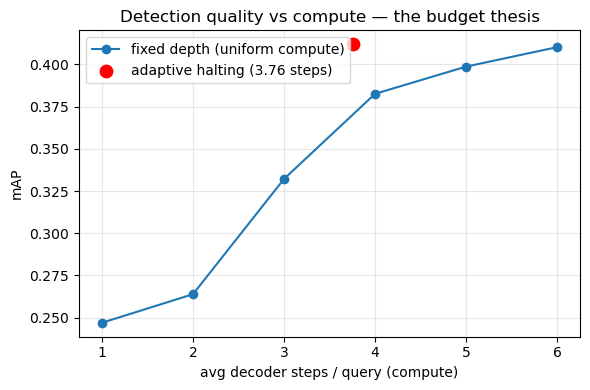


Reviewer reads this as: adaptive halting reaches ~deep-stack mAP at lower avg compute.


In [10]:
# ============================== 8a. HEADLINE: mAP-vs-COMPUTE CURVE ==============================
import matplotlib.pyplot as plt

if HAVE_VOC:
    model.load_state_dict(torch.load(best_path, map_location=device))
    pts = compute_curve(model, val_ld)
    print(f"{'mode':10s} {'depth':>5s} {'avg_steps':>9s} {'mAP':>7s} {'mAP50':>7s}")
    for mode,k,s,mp,m50 in pts:
        print(f"{mode:10s} {str(k):>5s} {s:9.2f} {mp:7.4f} {m50:7.4f}")

    fx = [(s,mp) for mode,k,s,mp,_ in pts if mode=="fixed"]
    ax_pt = [(s,mp) for mode,k,s,mp,_ in pts if mode=="adaptive"][0]
    plt.figure(figsize=(6,4))
    plt.plot([s for s,_ in fx], [mp for _,mp in fx], "o-", label="fixed depth (uniform compute)")
    plt.scatter([ax_pt[0]], [ax_pt[1]], c="red", zorder=5, s=80,
                label=f"adaptive halting ({ax_pt[0]:.2f} steps)")
    plt.xlabel("avg decoder steps / query (compute)"); plt.ylabel("mAP")
    plt.title("Detection quality vs compute — the budget thesis")
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
    plt.savefig(os.path.join(WEIGHTS_DIR,"compute_curve.png"), dpi=120); plt.show()
    print("\nReviewer reads this as: adaptive halting reaches ~deep-stack mAP at lower avg compute.")


In [11]:
# ============================== 8c. ADAPTIVE FRONTIER (the paper figure) ==============================
# One trained model, swept at inference by a halting THRESHOLD tau -> a whole
# accuracy/compute frontier, no retraining. Lower tau = halt earlier = cheaper.
# Also reports foreground halt depth (steps spent on queries that become real
# detections) so the saving is shown to be on real work, not just empty slots.

@torch.no_grad()
def halt_at_threshold(lam_logit, tau):
    S, B, Q = lam_logit.shape
    fire = lam_logit.sigmoid() >= tau
    fire[-1] = True                                 # always allowed to halt at last step
    return fire.float().argmax(0) + 1               # (B,Q) first firing step, 1..S

@torch.no_grad()
def readout_at_threshold(cls, box, lam_logit, img_sizes, tau, fg_score=0.3):
    S, B, Q, _ = cls.shape
    hs = halt_at_threshold(lam_logit, tau); idx = hs - 1
    cls_sel = torch.gather(cls, 0, idx[None,...,None].expand(1,B,Q,cls.size(-1)))[0]
    box_sel = torch.gather(box, 0, idx[None,...,None].expand(1,B,Q,4))[0]
    preds = postprocess(cls_sel, box_sel, img_sizes)
    sc = cls_sel.softmax(-1)[..., :-1].max(-1).values        # foreground confidence
    fg = sc > fg_score
    fg_steps = hs[fg].float().mean().item() if fg.any() else float("nan")
    return preds, hs.float().mean().item(), fg_steps

@torch.no_grad()
def evaluate_at_threshold(model, loader, tau):
    model.eval(); metric = MeanAveragePrecision(box_format="xyxy")
    all_steps, fg_steps_list, n = 0.0, [], 0
    for xs, targets in loader:
        xs = xs.to(device); sizes = [(IMG_SIZE, IMG_SIZE)]*xs.size(0)
        cls, box, lam = model(xs)
        preds, avg, fg = readout_at_threshold(cls, box, lam, sizes, tau)
        all_steps += avg*xs.size(0); n += xs.size(0)
        if fg == fg: fg_steps_list.append(fg)
        gts = [{"boxes": (box_cxcywh_to_xyxy(t["boxes"])*IMG_SIZE).to(device),
                "labels": t["labels"].to(device)} for t in targets]
        metric.update(preds, gts)
    res = metric.compute()
    fg_mean = float(np.mean(fg_steps_list)) if fg_steps_list else float("nan")
    return {k: float(v) for k,v in res.items() if v.numel()==1}, all_steps/max(1,n), fg_mean

def adaptive_frontier(model, loader, taus=(0.05,0.1,0.2,0.3,0.4,0.5,0.65,0.8,0.95)):
    pts = []
    for tau in tqdm(taus, desc="adaptive frontier"):
        m, avg, fg = evaluate_at_threshold(model, loader, tau)
        pts.append((tau, avg, fg, m["map"], m.get("map_50", float("nan"))))
    return pts


C:\Users\jesli\AppData\Local\Temp\ipykernel_15004\2269818847.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=dev

adaptive frontier:   0%|          | 0/9 [00:00<?, ?it/s]


  tau avg_steps fg_steps     mAP   mAP50
 0.05      3.03     5.19  0.4036  0.7495
 0.10      3.26     5.67  0.4069  0.7522
 0.20      3.50     5.87  0.4095  0.7572
 0.30      3.65     5.97  0.4115  0.7609
 0.40      3.82     6.00  0.4115  0.7611
 0.50      4.13     6.00  0.4116  0.7614
 0.65      6.00     6.00  0.4102  0.7602
 0.80      6.00     6.00  0.4102  0.7601
 0.95      6.00     6.00  0.4102  0.7601


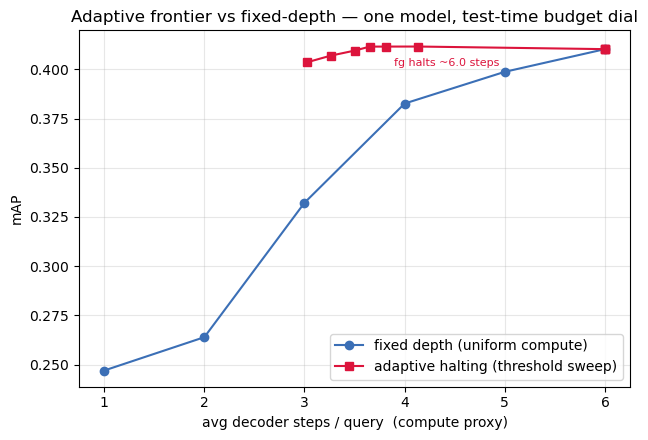


Red above/left of blue => more mAP per unit compute.
avg-steps is a faithful decoder-compute proxy (decoder cost ~ active-queries x layers);
a true early-exit kernel realizes the saving in wall-clock.


In [12]:
# ---- run + plot the frontier vs the fixed-depth baseline ----
if HAVE_VOC:
    model.load_state_dict(torch.load(best_path, map_location=device))
    fixed = []
    for k in range(1, NUM_STEPS+1):
        m, s = evaluate(model, val_ld, mode="fixed", fixed_depth=k)
        fixed.append((k, s, m["map"]))
    front = adaptive_frontier(model, val_ld)

    print(f"\n{'tau':>5s} {'avg_steps':>9s} {'fg_steps':>8s} {'mAP':>7s} {'mAP50':>7s}")
    for tau, avg, fg, mp, m50 in front:
        print(f"{tau:5.2f} {avg:9.2f} {fg:8.2f} {mp:7.4f} {m50:7.4f}")

    plt.figure(figsize=(6.5,4.5))
    plt.plot([s for _,s,_ in fixed], [mp for _,_,mp in fixed], "o-", color="#3b6fb6",
             label="fixed depth (uniform compute)")
    plt.plot([avg for _,avg,_,_,_ in front], [mp for *_,mp,_ in front], "s-", color="crimson",
             label="adaptive halting (threshold sweep)")
    mid = front[len(front)//2]
    plt.annotate(f"fg halts ~{mid[2]:.1f} steps", (mid[1], mid[3]),
                 textcoords="offset points", xytext=(6,-14), fontsize=8, color="crimson")
    plt.xlabel("avg decoder steps / query  (compute proxy)"); plt.ylabel("mAP")
    plt.title("Adaptive frontier vs fixed-depth — one model, test-time budget dial")
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
    plt.savefig(os.path.join(WEIGHTS_DIR,"adaptive_frontier.png"), dpi=120); plt.show()
    print("\nRed above/left of blue => more mAP per unit compute.")
    print("avg-steps is a faithful decoder-compute proxy (decoder cost ~ active-queries x layers);")
    print("a true early-exit kernel realizes the saving in wall-clock.")


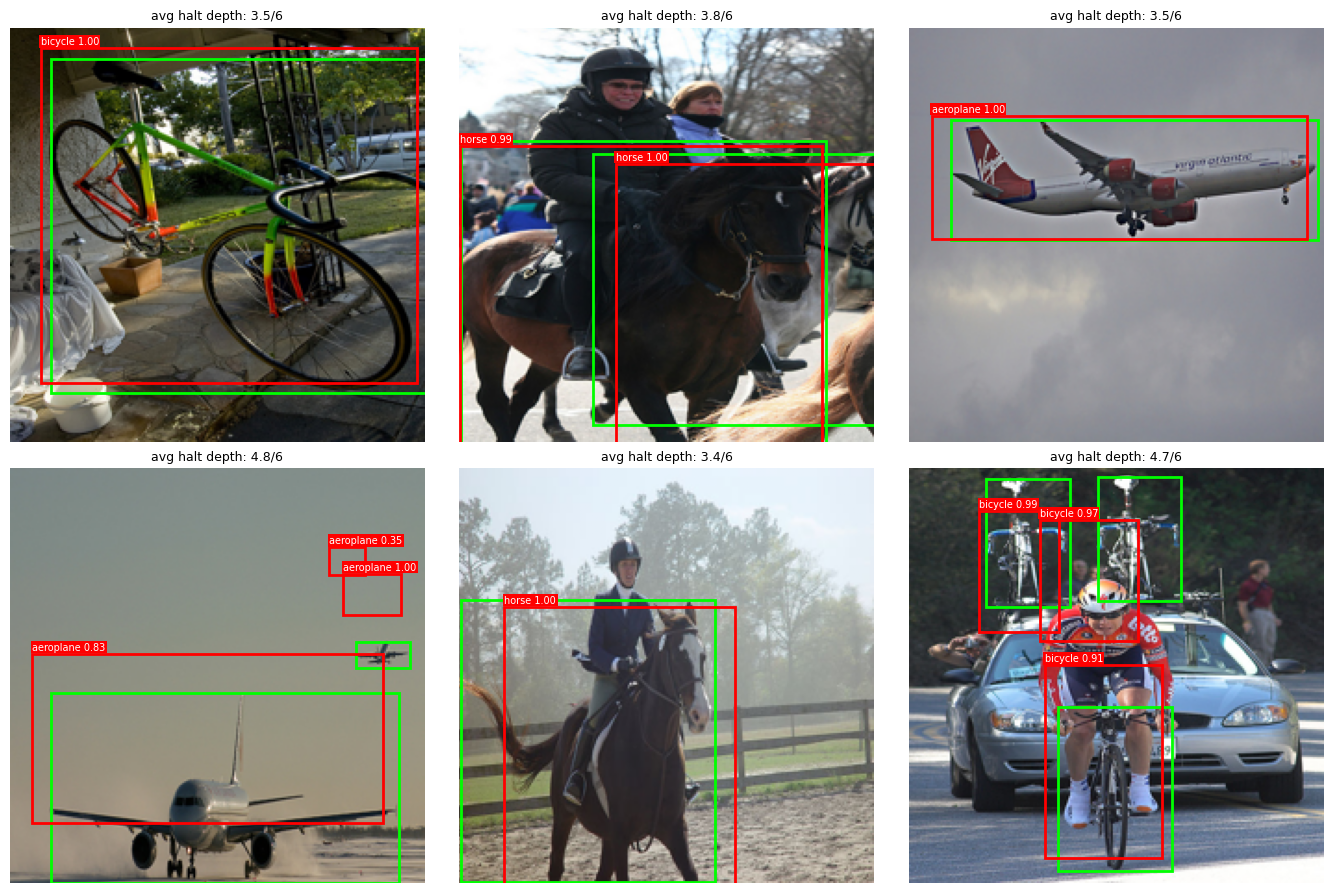

green = ground truth, red = predictions. Title shows how many steps queries used.


In [13]:
# ============================== 8b. VISUALISE DETECTIONS + HALT DEPTH ==============================
import matplotlib.patches as patches

@torch.no_grad()
def visualize(model, ids, n=6, score_thresh=0.3):
    model.eval()
    ds = VOCDetectionMulti(ids, PATH_VOC)
    pick = random.sample(range(len(ds)), min(n, len(ds)))
    cols = 3; rows = int(np.ceil(len(pick)/cols))
    fig, axs = plt.subplots(rows, cols, figsize=(cols*4.5, rows*4.5))
    axs = np.array(axs).reshape(-1)
    for ax_i, di in enumerate(pick):
        x, t = ds[di]
        cls, box, lam = model(x[None].to(device))
        hs, _ = halt_steps(lam)
        preds, _ = adaptive_readout(cls, box, lam, [(IMG_SIZE,IMG_SIZE)])
        p = {k: (v.cpu() if torch.is_tensor(v) else v) for k, v in preds[0].items()}
        img = (x*IMAGENET_STD + IMAGENET_MEAN).clamp(0,1).permute(1,2,0).numpy()
        ax = axs[ax_i]; ax.imshow(img); ax.axis("off")
        for gb in (box_cxcywh_to_xyxy(t["boxes"])*IMG_SIZE).cpu():
            ax.add_patch(patches.Rectangle((gb[0],gb[1]), gb[2]-gb[0], gb[3]-gb[1],
                         lw=2, edgecolor="lime", facecolor="none"))
        order = p["scores"].argsort(descending=True)
        for j in order[:6]:
            if p["scores"][j] < score_thresh: continue
            b = p["boxes"][j]
            ax.add_patch(patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1],
                         lw=2, edgecolor="red", facecolor="none"))
            ax.text(b[0], b[1]-2,
                    f"{IDX_TO_CLASS[int(p['labels'][j])]} {p['scores'][j]:.2f}",
                    color="white", fontsize=7, bbox=dict(fc="red", ec="none", pad=1))
        ax.set_title(f"avg halt depth: {hs.float().mean().item():.1f}/{NUM_STEPS}", fontsize=9)
    for k in range(len(pick), len(axs)): axs[k].axis("off")
    plt.tight_layout(); plt.show()

if HAVE_VOC:
    visualize(model, val_ids, n=6)
    print("green = ground truth, red = predictions. Title shows how many steps queries used.")


## 9. Ablations a CVPR reviewer will require

These are the experiments that turn "a working system" into "a defensible paper". Each one isolates
a claim. Run them by changing the noted config and re-running training + `compute_curve`.

1. **The budget sweep (the core result).** Train at `LAMBDA_P ∈ {0.2, 0.3, 0.4, 0.5, 0.6}` and overlay
   each model's adaptive point on the fixed-depth curve. The story is: adaptive points sit *above and
   to the left* of the fixed-depth frontier (more mAP per unit compute). Without this, there is no paper.
2. **Halting head on vs off.** Set `BETA=0` and read the final step only (no halting) → this is the
   plain deep-supervised DETR baseline. Show the halting policy buys compute at equal mAP. This is the
   ablation that proves the *novel* component does something — the exact thing the prior RL paper could
   never show for its action-history vector.
3. **Adaptive vs every fixed depth at matched compute.** For each adaptive avg-step value, compare to the
   fixed depth with the same compute. Adaptive should win — that's "spend compute where it's needed".
4. **Backbone scale / frozen vs fine-tuned.** `dinov2_vits14` → `dinov2_vitb14`; frozen vs last-block
   unfrozen. Shows the result isn't just backbone horsepower and quantifies the cost of unfreezing.
5. **Modern detector baseline (honesty table).** Run a frozen off-the-shelf detector on the same classes
   and report its mAP *and* its (fixed) compute. You will likely not beat it on raw mAP — your claim is
   the *compute-adaptivity axis*, so put both numbers on the same curve and let the frontier speak.
6. **Query count and `NUM_STEPS`.** Sensitivity of mAP/compute to `NUM_QUERIES` and max depth.
7. **Scale-up check.** Repeat on COCO (use a COCO `Dataset` with the same target dict format — the model,
   loss, and eval are dataset-agnostic). VOC-only will draw reviewer fire; COCO numbers are expected.

**Positioning to do before writing:** a focused 2024–2026 literature pass on *active / agentic / glimpse /
anytime / adaptive-computation detection* so you cite and beat the right neighbours rather than get
scooped. The contribution sentence to defend: *a learned per-instance compute-allocation policy for
detection over frozen foundation features, giving a favorable accuracy–compute frontier.*
